# Dataset与DataLoader

In [2]:
import os
import pandas as pd
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset
from PIL import Image
import torch


# 设置数据目录与标签CSV路径
data_dir = r"/mnt/workspace/cifar-10/train/train"
labels_csv = r"/mnt/workspace/cifar-10/trainLabels.csv"

# 1. 定义 CIFAR-10 的类别到整数索引的映射
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}

# 2. 加载标签CSV
df = pd.read_csv(labels_csv)
file_to_label = {}
for idx, row in df.iterrows():
    # 【修复关键点1】直接使用 id 和 .png 后缀，不补零
    file_name = f"{row['id']}.png"
    # 【修复关键点2】将字符串标签（如"frog"）转换为数字标签（如6）
    file_to_label[file_name] = class_to_idx[row['label']]

# 训练集使用数据增强抑制过拟合；验证集和测试集只做归一化。
normalize = transforms.Normalize((0.4917, 0.4823, 0.4467), (0.2024, 0.1995, 0.2010))
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    normalize,
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15), value='random'),
])
val_transform = transforms.Compose([
    transforms.ToTensor(),
    normalize,
])
# 保留 transform 名称供最后的测试集代码使用。
transform = val_transform

class MyImageDataset(Dataset):
    def __init__(self, folder, file_to_label, transform=None):
        self.folder = folder
        self.transform = transform
        self.file_to_label = file_to_label
        
        self.img_files = []
        for f in os.listdir(folder):
            if f.endswith(('.jpg', '.jpeg', '.png')):
                if f in self.file_to_label:
                    self.img_files.append(os.path.join(folder, f))
        
        # 按照文件名中的数字进行排序，保证顺序一致
        self.img_files.sort(key=lambda x: int(os.path.basename(x).split('.')[0]))
        
        # 打印一下实际加载到的图片数量，确保不再是 0
        print(f"成功匹配到 {len(self.img_files)} 张图片！")
        
    def __len__(self):
        return len(self.img_files)
    
    def __getitem__(self, idx):
        img_path = self.img_files[idx]
        image = Image.open(img_path).convert('RGB')
        basename = os.path.basename(img_path)
        
        # 此时获取到的已经是整数标签了
        label = self.file_to_label[basename]
        
        if self.transform:
            image = self.transform(image)
        return image, label

# 两份 Dataset 共享相同图片和划分索引，但分别使用训练/验证变换。
train_full_dataset = MyImageDataset(data_dir, file_to_label, transform=train_transform)
val_full_dataset = MyImageDataset(data_dir, file_to_label, transform=val_transform)
full_dataset = val_full_dataset
total_size = len(train_full_dataset)

# 固定随机种子，使每次运行都得到相同的训练/验证划分。
train_size = int(total_size * 0.9)
generator = torch.Generator().manual_seed(42)
indices = torch.randperm(total_size, generator=generator).tolist()
train_dataset = Subset(train_full_dataset, indices[:train_size])
val_dataset = Subset(val_full_dataset, indices[train_size:])

print(f"训练集大小: {len(train_dataset)}, 验证集大小: {len(val_dataset)}")

# 构造DataLoader
batch_size = 128
trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
valloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

成功匹配到 50000 张图片！
成功匹配到 50000 张图片！
训练集大小: 45000, 验证集大小: 5000


In [3]:
train_dataset[0][0].shape

torch.Size([3, 32, 32])

In [4]:
full_dataset[0][1]

6

In [5]:
for images, labels in trainloader:
    print(images.shape, labels.shape)
    break

torch.Size([128, 3, 32, 32]) torch.Size([128])


# 搭建模型

In [11]:
import torch
import torch.nn as nn

class VGG11(nn.Module):
    def __init__(self, num_classes=10):
        super(VGG11, self).__init__()
        # VGG11 特征提取部分（BN变体）
        self.features = nn.Sequential(
            # Conv1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.MaxPool2d(kernel_size=2, stride=2), # 32->16

            # Conv2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.MaxPool2d(kernel_size=2, stride=2), # 16->8

            # Conv3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # Conv4
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.MaxPool2d(kernel_size=2, stride=2), # 8->4

            # Conv5
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            # Conv6
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.MaxPool2d(kernel_size=2, stride=2), # 4->2

            # Conv7
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            # Conv8
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.MaxPool2d(kernel_size=2, stride=2) # 2->1
        )
        self.classifier = nn.Sequential(
            nn.Linear(512*1*1, 128),
            nn.ReLU(True),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model = VGG11(num_classes=10)
print(model)

VGG11(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(

In [12]:
# 做一个前向计算，验证模型
dummy_input = torch.randn(4, 3, 32, 32)  # batch_size=1, 3通道, 32x32图像
with torch.no_grad():
    output = model(dummy_input)
print("模型输出形状:", output.shape)

模型输出形状: torch.Size([4, 10])


In [13]:
# 统计模型参数量
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(model)
print(f"模型可训练参数总量: {total_params}")

模型可训练参数总量: 9292938


# 训练与可视化

使用设备: cuda
Epoch [1/20], Step [100/352], Loss: 1.7566
Epoch [1/20], Step [200/352], Loss: 1.7274
Epoch [1/20], Step [300/352], Loss: 1.4854
Epoch [1/20], Train Loss: 1.6298, Train Acc: 57.80%, Val Loss: 1.4005, Val Acc: 58.62%, LR: 0.050000
Best model saved at epoch 1.
Epoch [2/20], Step [100/352], Loss: 1.3662
Epoch [2/20], Step [200/352], Loss: 1.2421
Epoch [2/20], Step [300/352], Loss: 1.3538
Epoch [2/20], Train Loss: 1.2920, Train Acc: 66.10%, Val Loss: 1.2483, Val Acc: 66.48%, LR: 0.049692
Best model saved at epoch 2.
Epoch [3/20], Step [100/352], Loss: 1.1694
Epoch [3/20], Step [200/352], Loss: 1.1829
Epoch [3/20], Step [300/352], Loss: 1.1286
Epoch [3/20], Train Loss: 1.1601, Train Acc: 66.73%, Val Loss: 1.2079, Val Acc: 67.60%, LR: 0.048777
Best model saved at epoch 3.
Epoch [4/20], Step [100/352], Loss: 1.0186
Epoch [4/20], Step [200/352], Loss: 1.0308
Epoch [4/20], Step [300/352], Loss: 1.0352
Epoch [4/20], Train Loss: 1.0753, Train Acc: 74.44%, Val Loss: 1.0691, Val Acc: 75.

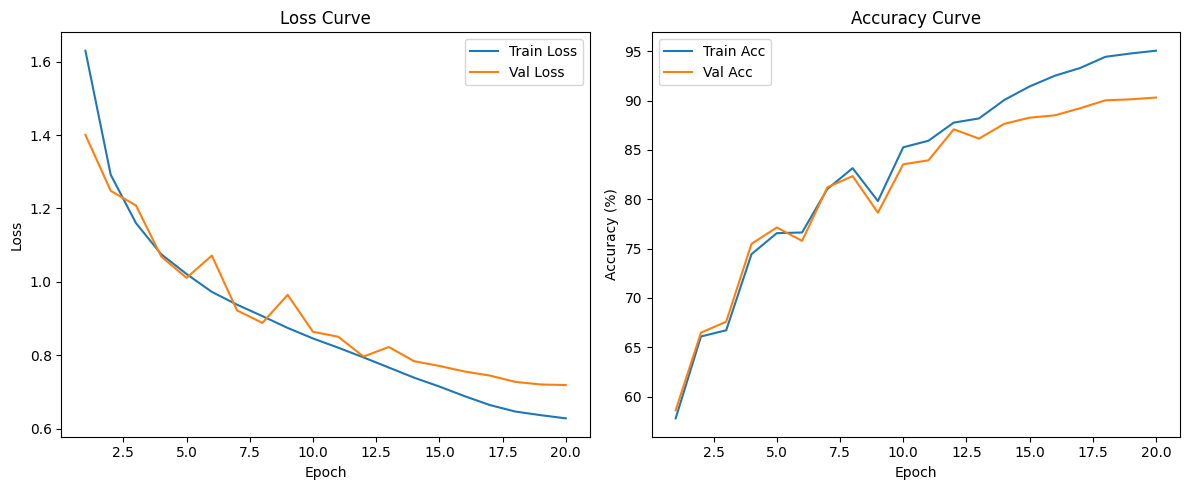

In [14]:
import torch.optim as optim
import importlib
import model_train
importlib.reload(model_train)  # 确保当前 Jupyter 内核使用刚更新的 Trainer
from model_train import Trainer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# CIFAR-10 常用配置：SGD + Nesterov + L2 正则 + 余弦退火。
epochs = 20
optimizer = optim.SGD(
    model.parameters(), lr=0.05, momentum=0.9, weight_decay=5e-4, nesterov=True
)
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
trainer = Trainer(
    model=model,
    trainloader=trainloader,
    valloader=valloader,
    optimizer=optimizer,
    lr=0.05,
    momentum=0.9,
    device=device,
    early_stop=True,
    early_stop_mode='val_acc',
    patience=10,
    save_path='cifar10_best_model.pth',
    criterion=criterion,
    scheduler=scheduler,
)

trainer.train(epochs=epochs)

# evaluating 的返回顺序是 (accuracy, average_loss)。
val_acc, val_loss = trainer.evaluating(valloader)
print(f"验证集损失: {val_loss:.4f}, 验证集准确率: {val_acc:.2f}%")
trainer.plot_metrics(acc=True)

# 测试集预测与提交

In [15]:
# 测试集预测并将结果写入 sampleSubmission.csv
import os
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader

test_dir = r"/mnt/workspace/cifar-10//test/test"
submission_path = r"/mnt/workspace/cifar-10/sampleSubmission.csv"
checkpoint_path = "cifar10_best_model.pth"

class Cifar10TestDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.folder = folder
        self.transform = transform
        self.img_files = [
            os.path.join(folder, name)
            for name in os.listdir(folder)
            if name.lower().endswith((".jpg", ".jpeg", ".png"))
        ]
        # 必须按数字 ID 排序，不能按字符串排序。
        self.img_files.sort(
            key=lambda path: int(os.path.splitext(os.path.basename(path))[0])
        )

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, index):
        img_path = self.img_files[index]
        image = Image.open(img_path).convert("RGB")
        image_id = int(os.path.splitext(os.path.basename(img_path))[0])
        if self.transform is not None:
            image = self.transform(image)
        return image, image_id

test_dataset = Cifar10TestDataset(test_dir, transform=transform)
test_loader = DataLoader(
    test_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=0,  # Windows/Jupyter 下使用 0 最稳妥
    pin_memory=torch.cuda.is_available(),
)
print(f"测试集大小: {len(test_dataset)}")

# 加载训练阶段保存的最佳权重。
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(
        f"未找到 {checkpoint_path}，请先运行上面的训练单元生成最佳模型权重。"
    )
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
model = model.to(device)
model.eval()

predicted_ids = []
predicted_labels = []
with torch.inference_mode():
    for images, image_ids in test_loader:
        images = images.to(device, non_blocking=True)
        class_indices = model(images).argmax(dim=1).cpu().tolist()
        predicted_ids.extend(image_ids.tolist())
        predicted_labels.extend(classes[index] for index in class_indices)

prediction_df = pd.DataFrame({"id": predicted_ids, "label": predicted_labels})
if prediction_df["id"].duplicated().any():
    raise ValueError("测试图片 ID 存在重复，无法生成可靠提交文件。")

# 以附件二的 ID 顺序为准写回，避免图片遍历顺序造成错位。
submission_df = pd.read_csv(submission_path)
if len(submission_df) != len(prediction_df):
    raise ValueError(
        f"提交模板有 {len(submission_df)} 行，但预测得到 {len(prediction_df)} 行。"
    )
submission_df = submission_df[["id"]].merge(
    prediction_df, on="id", how="left", validate="one_to_one"
)
if submission_df["label"].isna().any():
    missing_ids = submission_df.loc[submission_df["label"].isna(), "id"].head().tolist()
    raise ValueError(f"以下测试 ID 没有预测结果（仅显示前几个）: {missing_ids}")

submission_df.to_csv(submission_path, index=False)
print(f"预测完成，已写入: {submission_path}")
print(submission_df.head())
print(submission_df["label"].value_counts().sort_index())

测试集大小: 300000
预测完成，已写入: /mnt/workspace/cifar-10/sampleSubmission.csv
   id       label
0   1        deer
1   2    airplane
2   3  automobile
3   4        ship
4   5    airplane
label
airplane      27800
automobile    20863
bird          30296
cat           42584
deer          39137
dog           27855
frog          38267
horse         20812
ship          27294
truck         25092
Name: count, dtype: int64
